In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
path1 =r"H:\PYTHON\etapa3\atividade 6\Tabela 1.1.1.xlsx"
path2 = r"H:\PYTHON\etapa3\atividade 6\Tabela5-sem_emprego_2012.xlsx"
path3 = r"H:\PYTHON\etapa3\atividade 6\Tabela5-sem_emprego_2026.xlsx"


In [8]:
t1 = pd.read_excel(path1, skiprows=7)
t2012 = pd.read_excel(path2)
t2026 = pd.read_excel(path3)


In [9]:
t1 = t1.rename(columns={t1.columns[0]: "Estado", t1.columns[1]: "Horas_Cuidados_Total"})
t1 = t1.dropna(subset=["Estado"])

In [10]:
regioes = ["Brasil", "Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]
t1_estados = t1[~t1["Estado"].isin(regioes)].copy()
t1_estados["Estado"] = t1_estados["Estado"].str.strip()

In [11]:
t2012 = t2012.rename(columns={'Desocupados - mulheres (2012 T1)': 'mulheres_2012'})
t2026 = t2026.rename(columns={'Desocupados - mulheres (2026 T1)': 'mulheres_2026'})

In [13]:
comp = t2012.merge(t2026, on=["Sigla", "Código", "Estado"], how="inner")

comp_completo = comp.merge(t1_estados[["Estado", "Horas_Cuidados_Total"]], on="Estado", how="inner")
ordem = comp.sort_values("mulheres_2026", ascending=False)["Estado"]

In [14]:
longo = comp.melt(
    id_vars=["Sigla", "Código", "Estado"],
    value_vars=["mulheres_2012", "mulheres_2026"],
    var_name="Ano",
    value_name="Participacao_mulheres",
)

longo["Ano"] = longo["Ano"].map({"mulheres_2012": "2012 T1", "mulheres_2026": "2026 T1"})

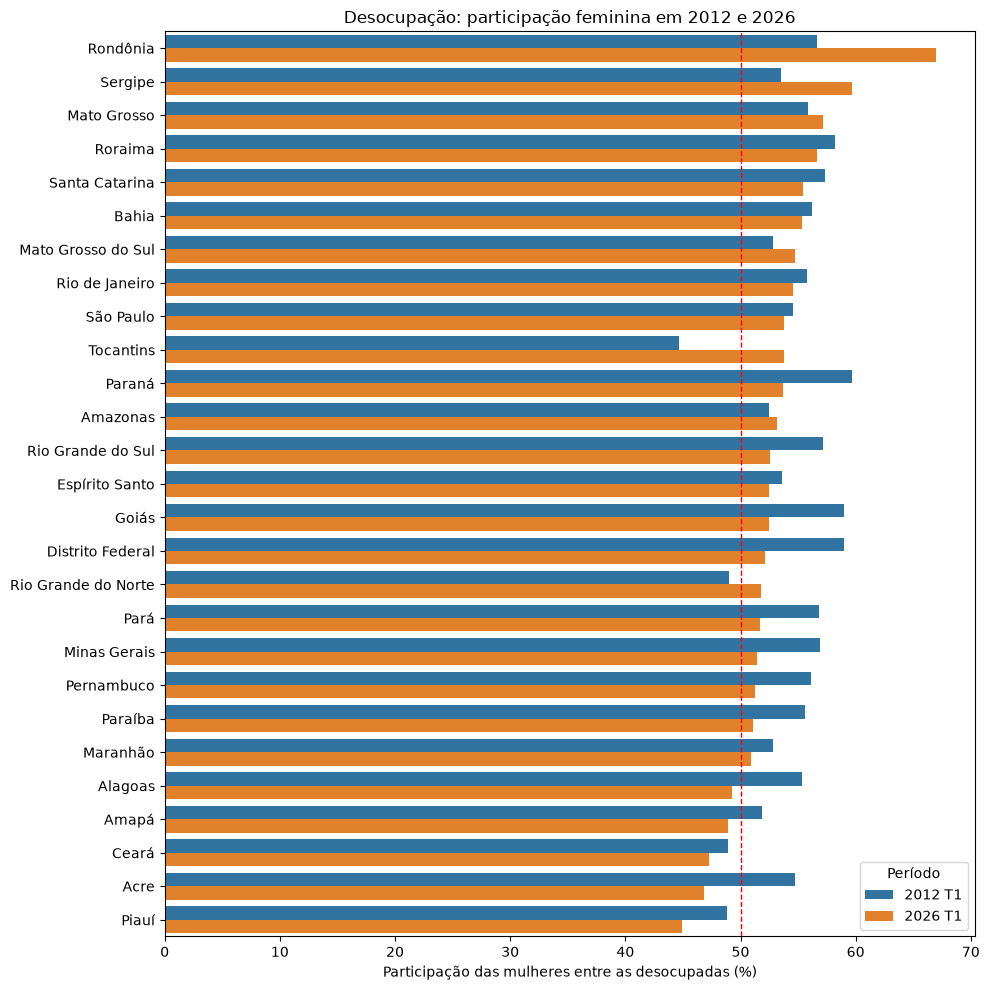

In [18]:
fig, ax = plt.subplots(figsize=(10, 10))

sns.barplot(
    data=longo, 
    y="Estado",
    x="Participacao_mulheres", 
    hue="Ano", 
    order=ordem,
    ax=ax,
)

ax.axvline(50, color="red", linestyle="--", linewidth=1) 
ax.set_xlabel("Participação das mulheres entre as desocupadas (%)")
ax.set_ylabel("")
ax.set_title("Desocupação: participação feminina em 2012 e 2026")

ax.legend(title="Período")

fig.tight_layout()

plt.show()